In [1]:


%load_ext autoreload
%autoreload 2

In [2]:

from typing import *

import cv2
import numpy as np
import ray
from ray import serve

from utils.gui import vis, vbbox, vic
from visual.models.diagram import BBox

In [3]:
ray.init()

2026-03-15 18:34:34,544	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 10.35.199.221:6379...
2026-03-15 18:34:34,570	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
/home/petr/study/diploma/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.11
Ray version:,2.54.0
Dashboard:,http://127.0.0.1:8265


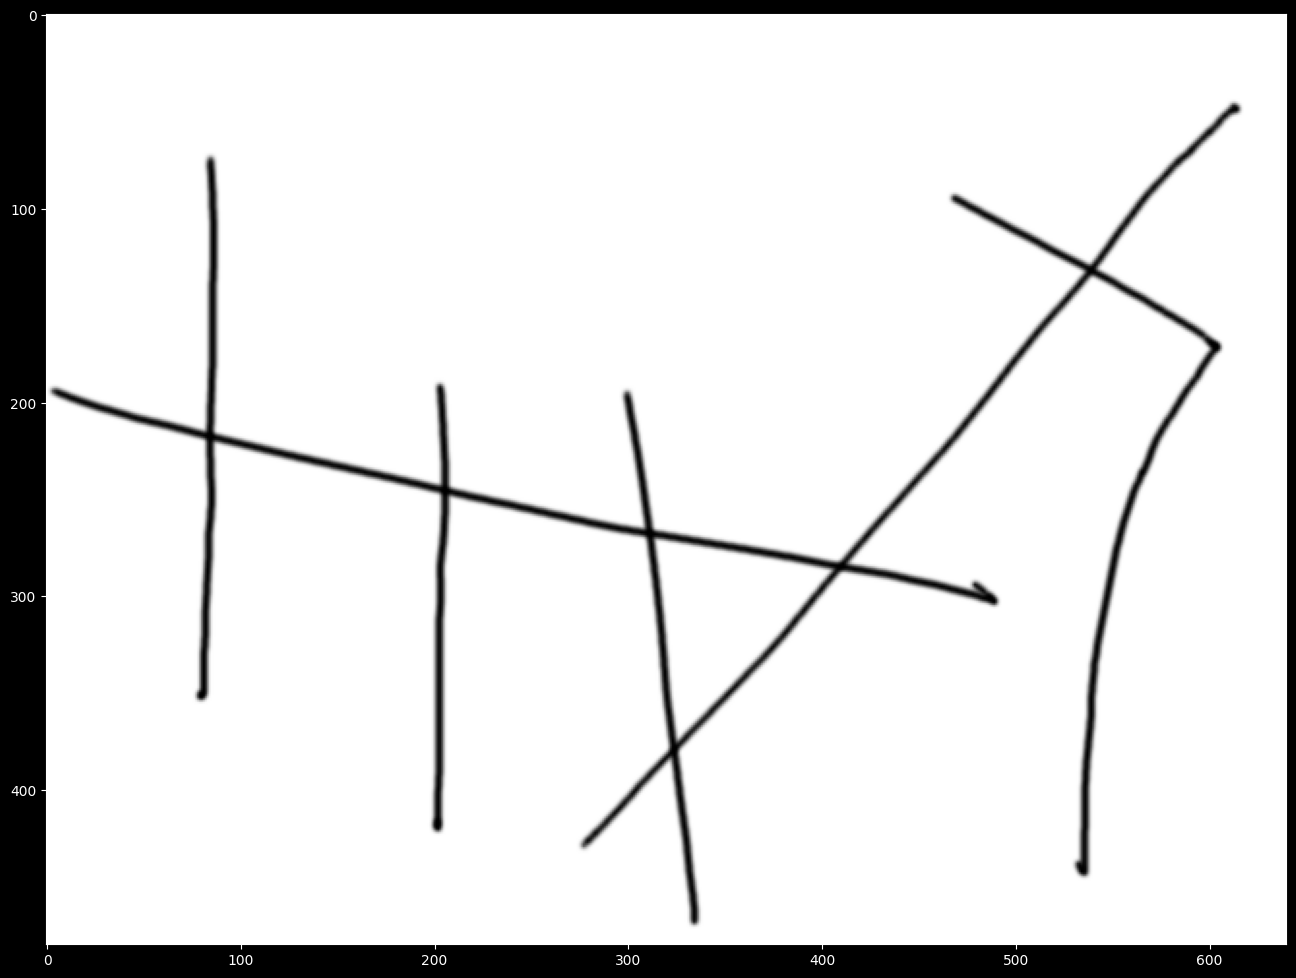

In [279]:
from utils.gui import stack_images

tests = {
    # "ed36a1594d570e76e0219bda981adb6c",
    # "/home/petr/study/diploma/src/datasetgen/full/f8e3fa2523fff97a2dc9c382dcb3b634.png",
    # "/home/petr/study/diploma/src/datasetgen/demo/6.png",
    "/home/petr/Documents/1.png",
    # "ec5ce1afe4d3c3d4c13470842eee7e5f"
}

orig = stack_images([
    cv2.imread(f"{i}")
    for i in tests
], 1, 1)
vis(orig)

In [280]:
# ocr = serve.get_deployment_handle("OCRReaderYandex", app_name="default")
ocr = serve.get_deployment_handle("OCRReaderEasyocr", app_name="ocr")

ocr_data = await ocr.remote(orig, dict(
    slope_ths=0.1,
    ycenter_ths=0.5,  # max shift y
    height_ths=0.4,  # max box height diff
    width_ths=0.5,  # max horizontal distance
    add_margin=0,
    x_ths=0.5,
    y_ths=0.5,
    paragraph=False
))
ocr_boxes, ocr_texts = ocr_data.boxes

# vis(vbbox(orig, ocr_boxes))

(ServeReplica:ocr:OCRReaderEasyocr pid=8120) [OCR] start
(ServeReplica:ocr:OCRReaderEasyocr pid=8120) [OCR] done #0 time 49ms


(ServeReplica:ocr:OCRReaderEasyocr pid=8120) INFO 2026-03-15 20:25:21,234 ocr_OCRReaderEasyocr yyc1t7xu 96d07386-da6b-40b3-b0a9-1b23964979e2 -- CALL __call__ OK 50.6ms


In [281]:
from visual.analyze.detection.model import DetectorObjectType
from shapely import Point, Polygon
from visual.analyze.structure.node import ImageGraphNode

dnd = serve.get_deployment_handle("DiagramNodesDetector", app_name="det")
bbs = await dnd.remote(orig)

nodes: List[ImageGraphNode] = []
arrowheads: List[Point] = []

for i in bbs:
    bb_poly: Polygon = i.bbox.polygon()
    if i.type == DetectorObjectType.NODE:
        nodes.append(ImageGraphNode(box=bb_poly))
    elif i.type == DetectorObjectType.ARROWHEAD:
        arrowheads.append(bb_poly.centroid)

node_bboxes = [i.bbox for i in bbs]
# vis(vbbox(orig, node_bboxes))

(ServeReplica:det:DiagramNodesDetector pid=8121) [YOLO-DIAG] Running
(ServeReplica:det:DiagramNodesDetector pid=8121) 
(ServeReplica:det:DiagramNodesDetector pid=8121) 0: 480x640 9 arrowheads, 209.4ms
(ServeReplica:det:DiagramNodesDetector pid=8121) Speed: 1.4ms preprocess, 209.4ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
(ServeReplica:det:DiagramNodesDetector pid=8121) [YOLO-DIAG] Detections: dict_items([(ARROWHEAD, 3)])


(ServeReplica:det:DiagramNodesDetector pid=8121) INFO 2026-03-15 20:25:24,192 det_DiagramNodesDetector 47tiblab 8db97163-449a-4440-bb9d-69e2473b8167 -- CALL __call__ OK 213.6ms


In [282]:
def bboxes2mask(bboxes: List[BBox], shape):
    mask = np.zeros(shape, dtype=np.uint8)
    for i in bboxes:
        x0, y0, x1, y1 = i.xyxy if isinstance(i, BBox) else i.bounds
        mask[y0:y1, x0:x1] = 0xFF
    return mask


def thresh(i):
    _, i = cv2.threshold(i, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return i


def threshv(i, v):
    _, i = cv2.threshold(i, v, 255, cv2.THRESH_BINARY_INV)
    return i


def preproc(i, textbbox):
    ig = cv2.cvtColor(i, cv2.COLOR_BGR2GRAY)
    _, it = cv2.threshold(ig, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    im = bboxes2mask(textbbox, it.shape)
    return it, it & ~im

In [283]:
ig = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
_, it = cv2.threshold(ig, 200, 255, cv2.THRESH_BINARY_INV)

# tgts = []
# tgts = [*ocr_boxes]
tgts = [*ocr_boxes, *node_bboxes]
del_bbx = [i.bbox_pad(0.05).int() for i in tgts]
del_mask = bboxes2mask(del_bbx, ig.shape)
im_clr = it & ~del_mask
# vic(orig, im_clr)

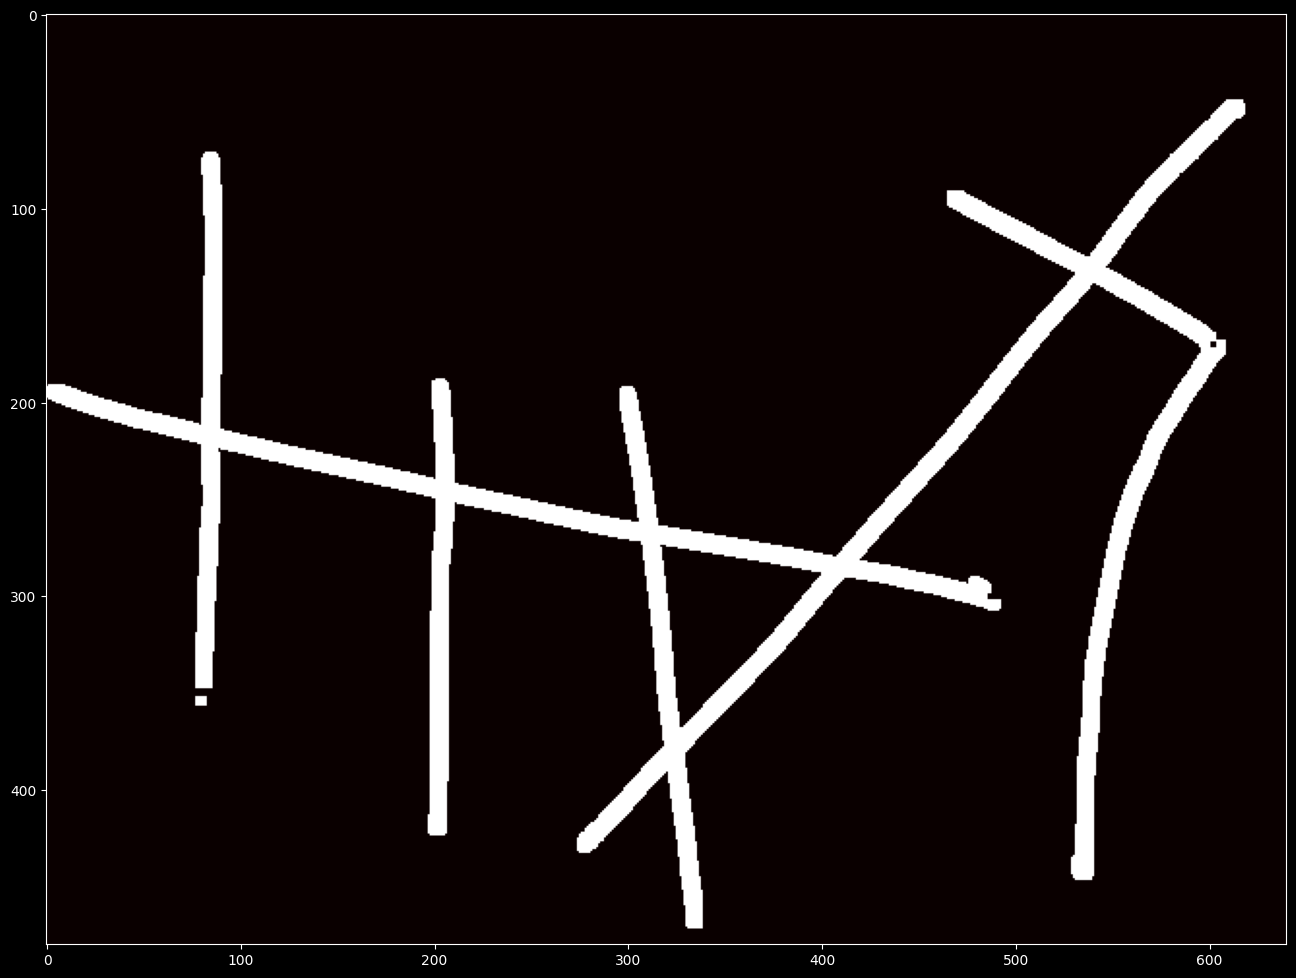

In [284]:
sz = 2
element = cv2.getStructuringElement(cv2.MORPH_RECT, (2 * sz + 1, 2 * sz + 1), (sz, sz))
dst = cv2.dilate(im_clr, element)
vis(dst)

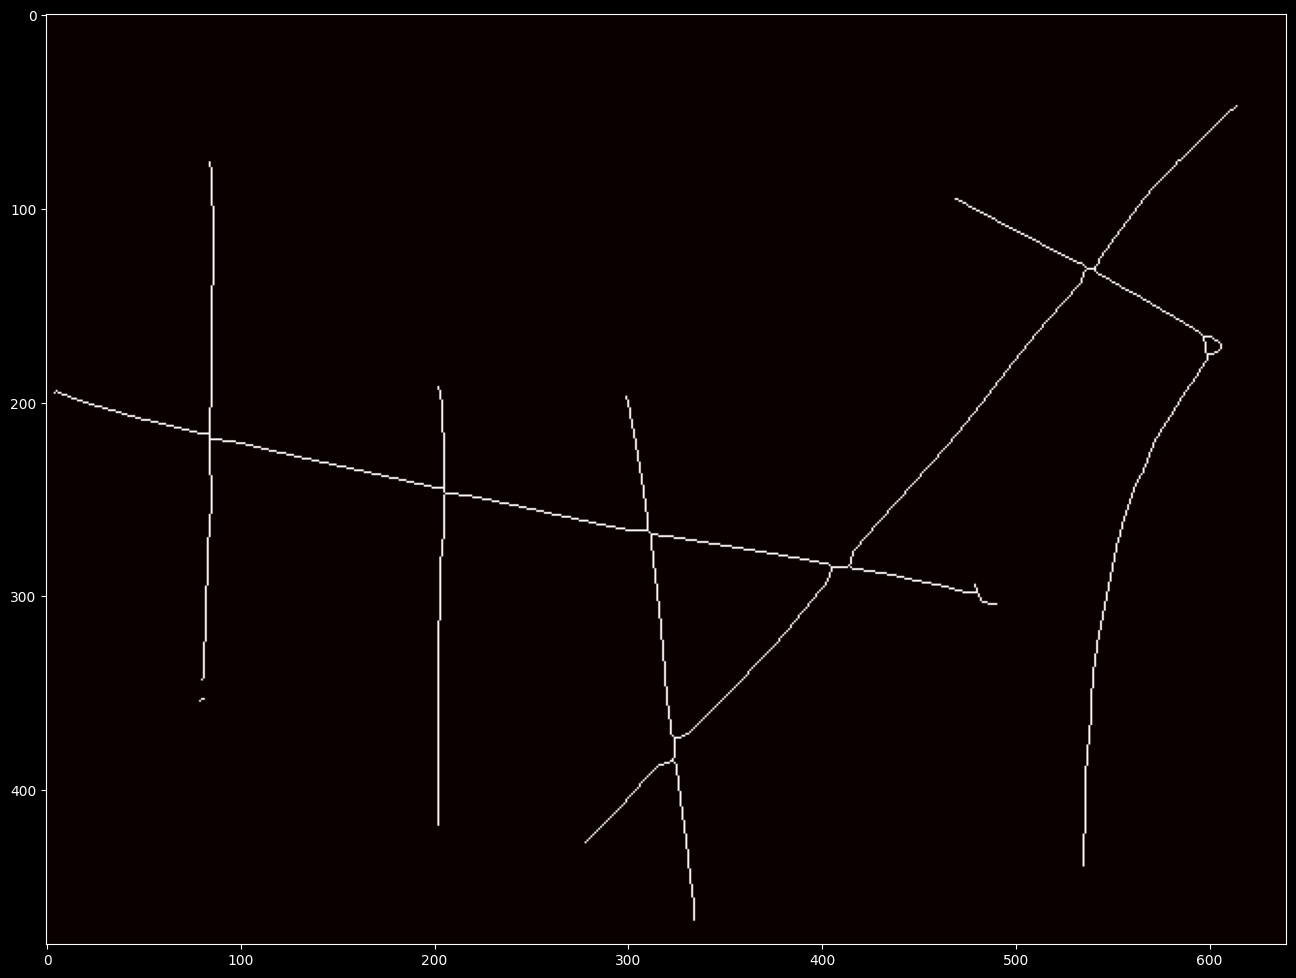

In [285]:
from skimage.morphology import skeletonize

dsts = skeletonize(dst).astype('uint8')
vis(dsts)

In [286]:

from sklearn.cluster import DBSCAN

box_kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=np.uint8)


def pts_from_mask(mask):
    return np.column_stack(np.where(mask > 0))[:, [1, 0]]


def detect_junctions(sk, selector=lambda i_sk, i_cnt: (i_cnt >= 3) & (i_sk == 1)):
    nb_cnt = cv2.filter2D(sk, -1, box_kernel)
    return pts_from_mask(selector(sk, nb_cnt))


def cluster_junctions(j_coord: np.ndarray, eps):
    dbs = DBSCAN(eps=eps, min_samples=1).fit(j_coord)
    res = []
    for i in set(dbs.labels_):
        pts = j_coord[dbs.labels_ == i]
        std = np.linalg.norm(pts.std(axis=0))
        cr = pts.mean(axis=0).astype(int)
        res.append((cr, std))
    return res


dsts_sep = dsts.copy()
j = detect_junctions(dsts)

# jcvis2 = cv2.cvtColor(dsts * 255, cv2.COLOR_GRAY2RGB)
for i in j:
    x, y = i
    dsts_sep[y, x] = 0

# jcvis2 = pts_vis(dsts * 255, j, circ=False, csize=10, xy_rev=False)

# jcvis = cv2.cvtColor(dsts * 255, cv2.COLOR_GRAY2RGB)
# for i in jc:
#     x, y = i[0]
#     cv2.circle(dsts_sep, imap(i[0]), 2*math.ceil(i[1]), (0, 0, 0), -1)
#     cv2.circle(jcvis, imap(i[0]), 2*math.ceil(i[1]), (255, 0, 0), 1)


cv2.imwrite("sk.png", dsts_sep * 255)

# vis(dsts_sep)
# vis(jcvis2)

True

In [287]:
from collections import deque

search_directions = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1), (0, 1),
    (1, -1), (1, 0), (1, 1)
]


def flood_ordered(image: np.ndarray, start_point) -> List[Tuple[int, int, int, int]]:
    if not image[start_point]:
        return []
    result = [start_point]
    visited = np.zeros_like(image, dtype=bool)
    visited[start_point] = True
    queue = deque([(*start_point, 0, 0)])
    while queue:
        r, c, dr, dc = queue.popleft()
        for d_row, d_col in search_directions:
            new_r, new_c = r + d_row, c + d_col
            if not (0 <= new_r < image.shape[0] and 0 <= new_c < image.shape[1]):
                continue
            if image[new_r, new_c] and not visited[new_r, new_c]:
                result.append((new_r, new_c))
                visited[new_r, new_c] = True
                queue.append((new_r, new_c, d_row, d_col))
    return np.array(result)

def flood_ordered_inplace(image: np.ndarray, start_point) -> List[Tuple[int, int, int, int]]:
    if not image[start_point]:
        return []
    result = [start_point]
    image[start_point] = 0
    queue = deque([(*start_point, 0, 0)])
    while queue:
        r, c, dr, dc = queue.popleft()
        for d_row, d_col in search_directions:
            new_r, new_c = r + d_row, c + d_col
            if not (0 <= new_r < image.shape[0] and 0 <= new_c < image.shape[1]):
                continue
            if image[new_r, new_c]:
                result.append((new_r, new_c))
                image[new_r, new_c] = 0
                queue.append((new_r, new_c, d_row, d_col))
    return np.array(result)


[flood]: #54 time=0.111±0.168ms total=6.0ms
[rdp]: #19 time=2.021±2.464ms total=38.4ms


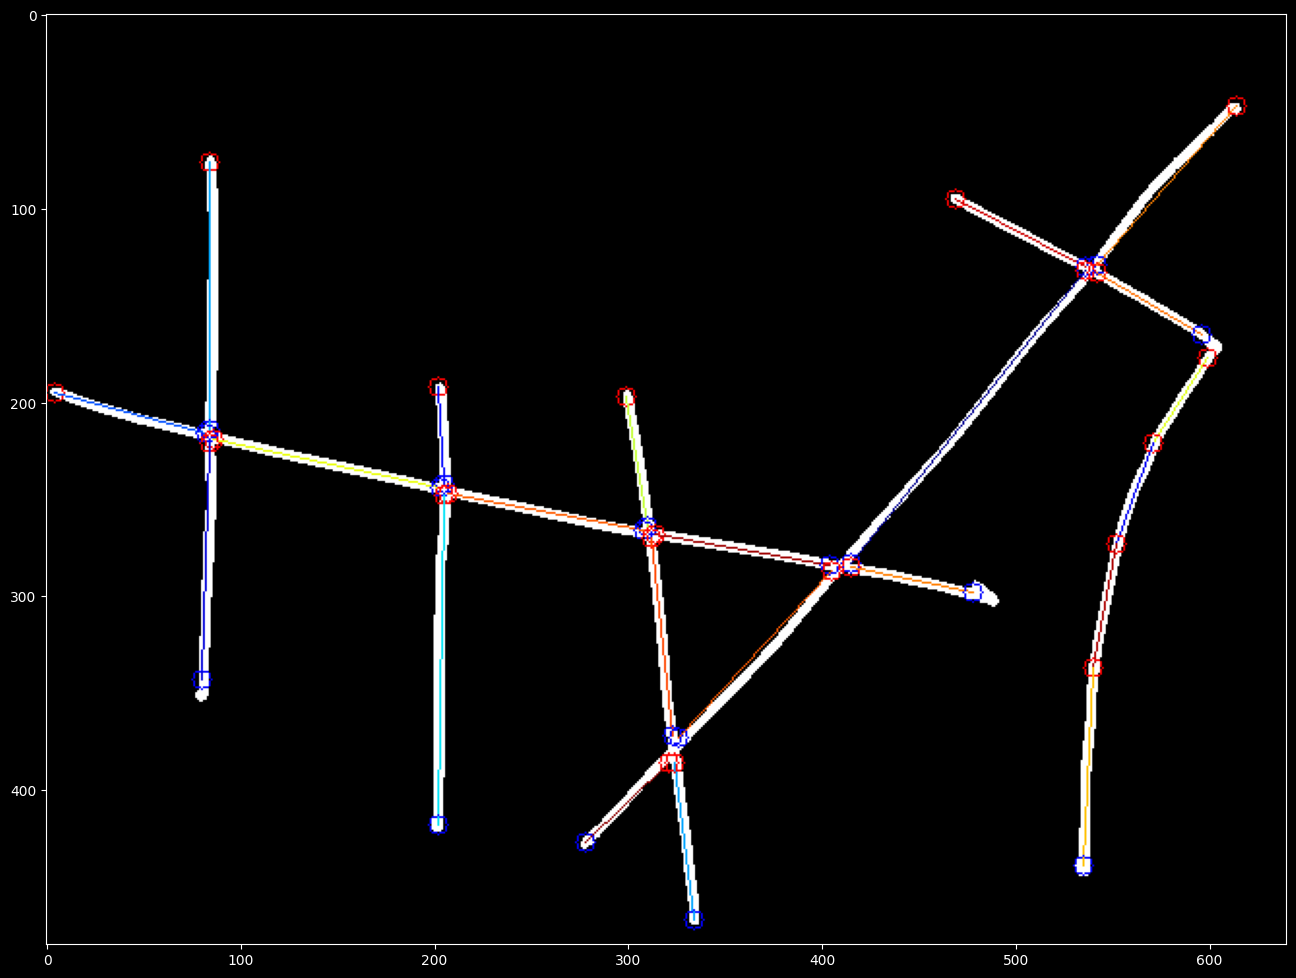

In [288]:
from utils.func import stat
from shapely import LineString
from utils.gui import vis_ls
from rdp import rdp

# sk_comps_n, sk_comps = cv2.connectedComponents(dsts_sep, connectivity=8)
sk_ends = detect_junctions(dsts_sep, lambda i_sk, i_cnt: (i_cnt == 1) & (i_sk == 1))

input_segments: List[LineString] = []
in_seg_pts = []

flood_skel = dsts_sep.copy()

min_comp_size = 20
with stat() as M:
    for ep in sk_ends:
        with M("flood"):
            pts = flood_ordered_inplace(flood_skel, tuple(ep[::-1]))
        if len(pts) < min_comp_size:
            continue
        with M("rdp"):
            segmented = rdp(pts, epsilon=5)[:, [1, 0]]

        for i in zip(segmented, segmented[1:]):
            in_seg_pts.append([Point(j) for j in i])
            input_segments.append(LineString(i))

vis(vis_ls(it, input_segments))

In [298]:
from visual.analyze.linegraph import GEdge
from utils.geom import m_angle
from math import radians
from utils.geom import seg_pts
from shapely import Point, STRtree

def score_partial(val, v_min, v_max):
    scaled = (val - v_min) / (v_max - v_min)
    return scaled if v_min <= val <= v_max else np.inf


def join_score_step1(own_seg: GEdge, next_seg: GEdge):
     # ep_next_b <- [ep_next_a] & [ep_own_a] -> ep_own_b
    ep_own_a, ep_own_b = own_seg.pts
    ep_next_a, ep_next_b = next_seg.pts

    conn_dist = ep_next_a.distance(ep_own_a)
    diff_angle = abs(m_angle(own_seg.pts[::-1], next_seg.pts))
    scores = np.array([
        score_partial(conn_dist, 0, 20),
        score_partial(diff_angle, 0, radians(25)),
    ])
    return np.linalg.norm(scores) ** 2


def rank_pairs(ranker, own_seg: GEdge, others: List[GEdge], max_score=1) -> List[Tuple[float, GEdge]]:
    variants = [(score, i)
                for i in others
                if (score := ranker(own_seg, i)) < max_score]
    variants.sort(key=lambda i: i[0])
    return variants



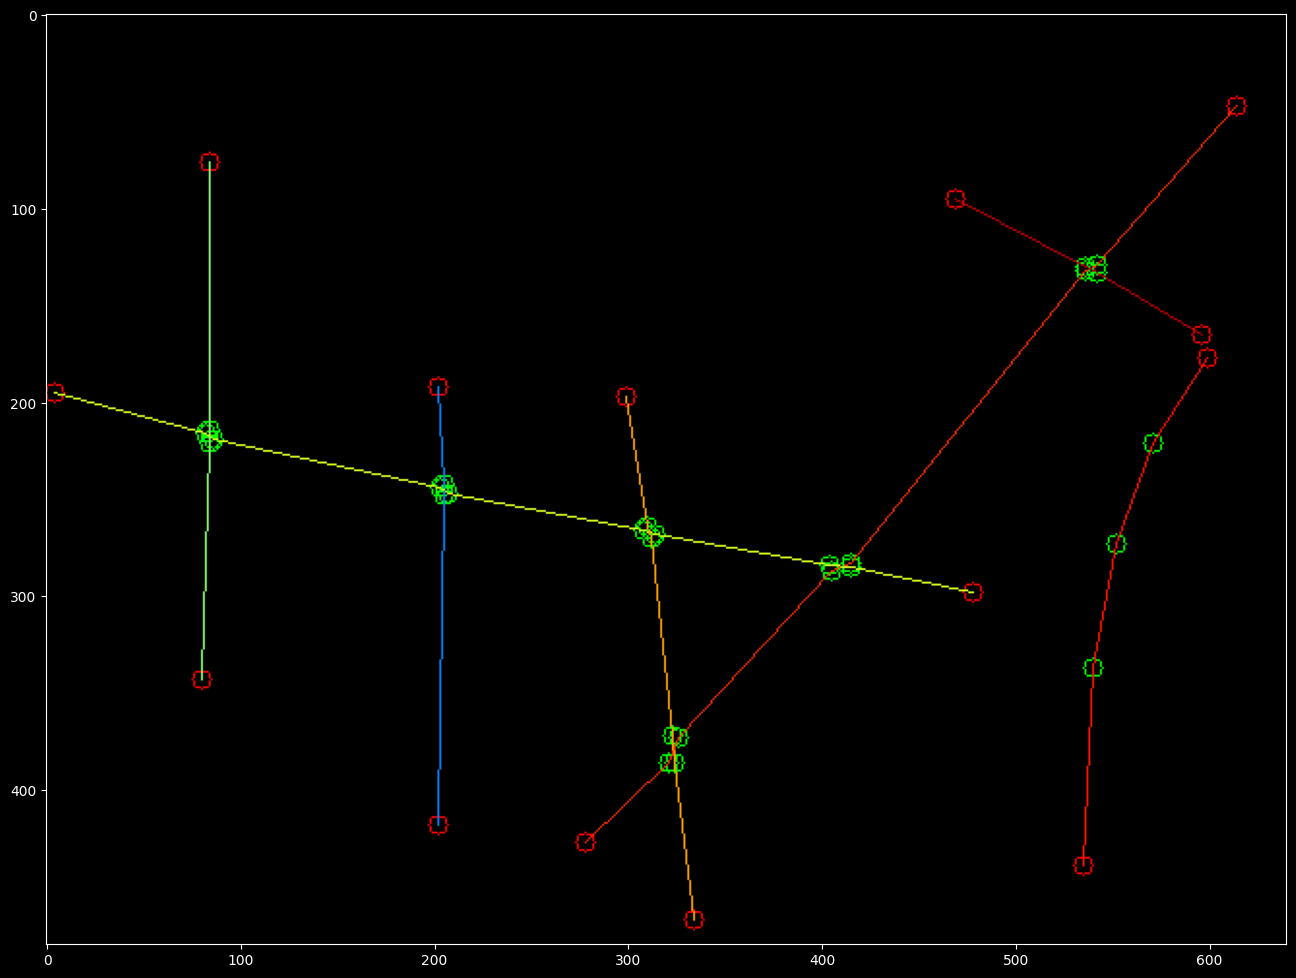

In [302]:
from utils.gui import vis_arrow, color_range_01, vis_circ
from visual.analyze.linegraph import LineGraph

vislg = np.zeros_like(orig)

lg = LineGraph()
# lg.add_segments(in_seg_pts[100:300])
lg.add_segments(in_seg_pts)

to_process = [i.uid for i in lg.unbound_nodes()]

dn = False
for nid in to_process:
    node = lg.node(nid)
    if node.typ != NType.UNBOUND: continue
    if (proposal := lg.propose_for_node(nid)) is None: continue
    cur_edge, proposed_edges = proposal

    variants = rank_pairs(join_score_step1, cur_edge, proposed_edges, max_score=1)
    if len(variants) == 0: continue

    col = color_range_01()
    score, other_edge = variants[0]
    lg.connect(cur_edge.u_start, other_edge.u_start, CType.SOFT, NType.BOUND_INT)

    # print(score, cur_edge, other_edge)
    # pt_as, pt_ae = [i.uid for i in cur_edge.nds]
    # pt_bs, pt_be = [i.uid for i in other_edge.nds]
    # vis_arrow(vislg, cur_edge.nds[0].pt, cur_edge.nds[1].pt, col)
    # vis_arrow(vislg, other_edge.nds[0].pt, other_edge.nds[1].pt, col)
    # lg.mark_node(pt_as, NType.BOUND_INT)
    # lg.mark_node(pt_bs, NType.BOUND_INT)
    # lg.mark_node(pt_bs, NType.BOUND_START)
    # lg.mark_node(pt_be, NType.BOUND_INT)

# vis(vislg)
# vis(lg.vis(dst))
vis(lg.vis(np.zeros_like(it)))

In [221]:
# iseg_endpoints = [Point(i) for seg in input_segments for i in seg.coords]
# ep_idx_to_seg_idx = [i for i, sg in enumerate(input_segments) for _ in range(len(sg.coords))]
# endpoints_tree = STRtree(iseg_endpoints)
#
# unbound_ep_idx = set(range(len(iseg_endpoints)))
# bindings_step1 = list()
#
# for ep_idx, ep in enumerate(iseg_endpoints):
#     if ep_idx not in unbound_ep_idx: continue
#     cur_polyline: LineString = input_segments[ep_idx_to_seg_idx[ep_idx]]
#     cur_seg: LineString = get_linestring_last_segment(cur_polyline, ep)
#     ep_own_a, ep_own_b = seg_pts(cur_seg)  # a -> b(ep)
#
#     near_ep_idx = endpoints_tree.query(ep, predicate="dwithin", distance=1)
#     near_ep_idx = [
#         (i, iseg_endpoints[i])
#         for i in near_ep_idx
#         if i in unbound_ep_idx and i != ep_idx
#     ]
#     print("@@@")
#     print(f"{ep_idx=} {ep=} {ep_own_a=} {ep_own_b=}")
#     print(near_ep_idx)
#     print([input_segments[ep_idx_to_seg_idx[i[0]]] for i in near_ep_idx])
#     continue
#
#     variants = []
#     for next_ep_idx, next_ep in near_ep_idx:
#         next_polyline: LineString = input_segments[ep_idx_to_seg_idx[next_ep_idx]]
#         next_seg: LineString = get_linestring_last_segment(next_polyline, next_ep)
#         # ep_next_a, ep_next_b = seg_pts(next_seg) # own_a -> own_b & next_b <- next_a
#         score = join_score_step1(cur_seg, next_seg)
#         variants.append((score, next_seg, next_ep_idx, next_ep))
#
#     variants.sort(key=lambda x: x[0])
#     if len(variants) and variants[0][0] < 0.01:
#         score, n_seg, n_seg_ep_id, n_seg_ep = variants[0]
#         # print("!", score)
#         unbound_ep_idx.remove(n_seg_ep_id)
#         unbound_ep_idx.remove(ep_idx)
#         bindings_step1.append((ep_idx, n_seg_ep_id))
#
# lss = []
# for ea, eb in bindings_step1:
#     print(ea, eb)
#     lss.append(LineString((iseg_endpoints[ea], iseg_endpoints[eb])))
#
# vis(vis_ls(it, lss))

In [243]:
import networkx as nx

g= nx.Graph()
g.add_node("1")
g.add_node("2")
g.add_node("3")
g.add_node("4")
g.add_edge("1","2")
g.add_edge("2","3")
g.add_edge("3","1")
g.nodes(data=True)

{}